# QTM 151 Final Project
## Voting Alignment Across Presidential, Gubernatorial, and Senate Elections

Ayushi Chowksey, Shraddha Bandlamudi, Jillian Koenig, Johnny Sanchez

## Introduction

This project examines whether counties vote consistently for the same political party across different levels of U.S. elections. Specifically, we analyze:

1. Whether counties that voted for the winning **presidential** candidate’s party also voted for the winning **gubernatorial** candidate’s party.  
2. Whether counties that voted for the winning **governor** also supported the winning **U.S. Senate** candidate.

Understanding these relationships helps us measure the strength of partisan alignment within counties and identify where split-ticket voting or mixed outcomes occur. After computing alignment percentages, we deepen our analysis by comparing:

- states that lean Democratic vs Republican  
- geographic regions (Northeast, Midwest, South, West)  
- patterns emerging from state-level and region-level alignment  

## Data Description

We use three county-level datasets from the 2020 U.S. Elections:

- **president_county_candidate.csv**
- **governors_county_candidate.csv**
- **senate_county_candidate.csv**

Each dataset contains:
- one row per *candidate* per county  
- vote totals (`votes` or `total_votes`)  
- the candidate’s political party  
- `won` indicator showing whether the candidate won the county  

Before merging datasets, we extract only the winning candidate in each county for each race. This gives us a clean table where each county has exactly one presidential winner, one gubernatorial winner, and one Senate winner.

We then merge the three winner tables using `merge()` on `state` and `county`, allowing us to compare party alignment across election types.

## Importing Libraries

We use:
- `pandas` for data manipulation  
- `numpy` for numeric operations  
- `matplotlib.pyplot` for visualizations  

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

We load all three candidate-level datasets and preview the structure using `head()`.

## Data Loading
Explain loading.

In [2]:
df_pres = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
df_gov = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")
df_sen = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")

df_pres.head(), df_gov.head(), df_sen.head()

(      state             county      candidate party  total_votes    won
 0  Delaware        Kent County      Joe Biden   DEM        44552   True
 1  Delaware        Kent County   Donald Trump   REP        41009  False
 2  Delaware        Kent County   Jo Jorgensen   LIB         1044  False
 3  Delaware        Kent County  Howie Hawkins   GRN          420  False
 4  Delaware  New Castle County      Joe Biden   DEM       195034   True,
       state             county        candidate party   votes    won
 0  Delaware        Kent County      John Carney   DEM   44352   True
 1  Delaware        Kent County  Julianne Murray   REP   39332  False
 2  Delaware        Kent County  Kathy DeMatteis   IPD    1115  False
 3  Delaware        Kent County    John Machurek   LIB     616  False
 4  Delaware  New Castle County      John Carney   DEM  191678   True,
       state             county      candidate party  total_votes
 0  Delaware        Kent County  Lauren Witzke   REP        38571
 1  Dela

## Extracting County Winners

Each dataset contains multiple candidates per county.  
To identify the winning candidate, we filter rows where `won == True`.

We also rename columns to keep party and vote variables clearly labeled.

In [3]:
# extracting County Winners
pres_win = df_pres[df_pres["won"] == True][["state","county","party","total_votes"]]
pres_win = pres_win.rename(columns={"party":"pres_party", "total_votes":"pres_votes"})

gov_win = df_gov[df_gov["won"] == True][["state","county","party","votes"]]
gov_win = gov_win.rename(columns={"party":"gov_party", "votes":"gov_votes"})

pres_win.head(), gov_win.head()

(                   state                county pres_party  pres_votes
 0               Delaware           Kent County        DEM       44552
 4               Delaware     New Castle County        DEM      195034
 8               Delaware         Sussex County        REP       71230
 12  District of Columbia  District of Columbia        DEM       39041
 19  District of Columbia                Ward 2        DEM       29078,
        state             county gov_party  gov_votes
 0   Delaware        Kent County       DEM      44352
 4   Delaware  New Castle County       DEM     191678
 8   Delaware      Sussex County       REP      68435
 12   Indiana       Adams County       REP       9441
 15   Indiana       Allen County       REP      98406)

## Extracting Senate Winners

Unlike the other tables, `senate_county_candidate.csv` does not include a `won` indicator.  
Instead, we identify winners using `groupby` and selecting the candidate with the maximum vote total per county.


In [4]:
# extracting senate winners
sen_winner = df_sen.groupby(["state","county"])["total_votes"].max().reset_index()
df_sen_win = pd.merge(df_sen, sen_winner, on=["state","county","total_votes"], how="inner")

df_sen_win = df_sen_win[["state","county","party","total_votes"]]
df_sen_win = df_sen_win.rename(columns={"party":"sen_party","total_votes":"sen_votes"})

df_sen_win.head()

,state,county,sen_party,sen_votes
0,Delaware,Kent County,REP,38571
1,Delaware,New Castle County,REP,80081
2,Delaware,Sussex County,DEM,56137
3,Georgia,Baker County,DEM,648
4,Georgia,Baldwin County,DEM,8783


## Merging Presidential and Gubernatorial Winners

We use `merge()` on the shared keys (`state`, `county`) to align the winner tables.

We then create a boolean column `same_party_pres_gov` that checks whether the presidential and governor winners belonged to the same party.

In [5]:
# merging datasets
pres_gov = pd.merge(pres_win, gov_win, on=["state","county"], how="inner")
pres_gov["same_party_pres_gov"] = pres_gov["pres_party"] == pres_gov["gov_party"]
pres_gov.head()

pres_gov.head()

,state,county,pres_party,pres_votes,gov_party,gov_votes,same_party_pres_gov
0,Delaware,Kent County,DEM,44552,DEM,44352,True
1,Delaware,New Castle County,DEM,195034,DEM,191678,True
2,Delaware,Sussex County,REP,71230,REP,68435,True
3,Indiana,Adams County,REP,10686,REP,9441,True
4,Indiana,Allen County,REP,92083,REP,98406,True





## Merging Governor and Senate Winners

We repeat the merge process to analyze governor–senate alignment.


In [6]:
# extracting County Winners
pres_win = df_pres[df_pres["won"] == True][["state","county","party","total_votes"]]
pres_win = pres_win.rename(columns={"party":"pres_party", "total_votes":"pres_votes"})

gov_win = df_gov[df_gov["won"] == True][["state","county","party","votes"]]
gov_win = gov_win.rename(columns={"party":"gov_party", "votes":"gov_votes"})

# extracting senate winners
sen_winner = df_sen.groupby(["state","county"])["total_votes"].max().reset_index()
df_sen_win = pd.merge(df_sen, sen_winner, on=["state","county","total_votes"], how="inner")

df_sen_win = df_sen_win[["state","county","party","total_votes"]]
df_sen_win = df_sen_win.rename(columns={"party":"sen_party","total_votes":"sen_votes"})

# merging datasets
pres_gov = pd.merge(pres_win, gov_win, on=["state","county"], how="inner")
pres_gov["same_party_pres_gov"] = pres_gov["pres_party"] == pres_gov["gov_party"]
pres_gov.head()

# merging governor and senate winners
gov_sen = pd.merge(gov_win, df_sen_win, on=["state","county"], how="inner")
gov_sen["same_party_gov_sen"] = gov_sen["gov_party"] == gov_sen["sen_party"]
gov_sen.head()

,state,county,gov_party,gov_votes,sen_party,sen_votes,same_party_gov_sen
0,Delaware,Kent County,DEM,44352,REP,38571,False
1,Delaware,New Castle County,DEM,191678,REP,80081,False
2,Delaware,Sussex County,REP,68435,DEM,56137,False
3,Montana,Beaverhead County,REP,3779,DEM,1890,False
4,Montana,Big Horn County,DEM,2513,REP,2106,False


## Descriptive Statistics

We summarize vote totals for each race using `.describe()`, which provides count, mean, standard deviation, and quartiles.

In [7]:
pres_gov[["pres_votes","gov_votes"]].describe()


,pres_votes,gov_votes
count,1025.000000,1025.000000
mean,12695.991220,12487.689756
std,42922.320095,42228.752855
min,5.000000,4.000000
25%,682.000000,742.000000
50%,2575.000000,2663.000000
75%,9573.000000,9076.000000
max,907310.000000,887374.000000


## Plot 1: Frequency of Same-Party Presidential vs Governor Winners

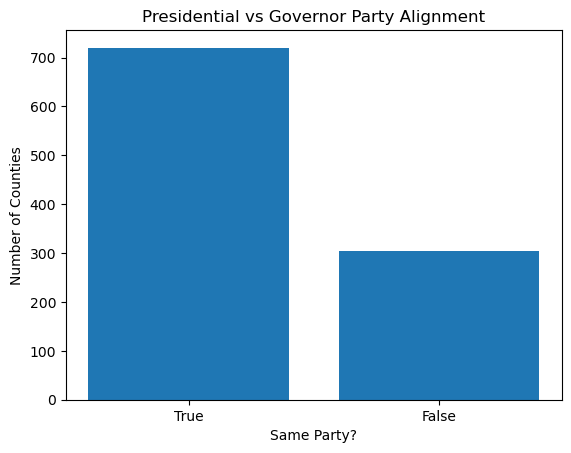

In [8]:
counts = pres_gov["same_party_pres_gov"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Same Party?")
plt.ylabel("Number of Counties")
plt.title("Presidential vs Governor Party Alignment")
plt.show()

## Plot 2: Presidential vs Governor Alignment by Party of Governor
We examine whether Democrat-led vs Republican-led states differ in alignment rates.

In [9]:
state_gov_party = gov_win.groupby("state")["gov_party"].agg(lambda x: x.mode()[0]).reset_index()

pg_state = pres_gov.groupby("state")["same_party_pres_gov"].mean().reset_index()

pg_merged = pd.merge(state_gov_party, pg_state, on="state")
pg_merged.head()

,state,gov_party,same_party_pres_gov
0,Delaware,DEM,1.000000
1,Indiana,REP,0.978261
2,Missouri,REP,1.000000
3,Montana,REP,0.964286
4,New Hampshire,REP,0.586498


## Plot 3: Presidential–Gubernatorial Alignment by Governor Party

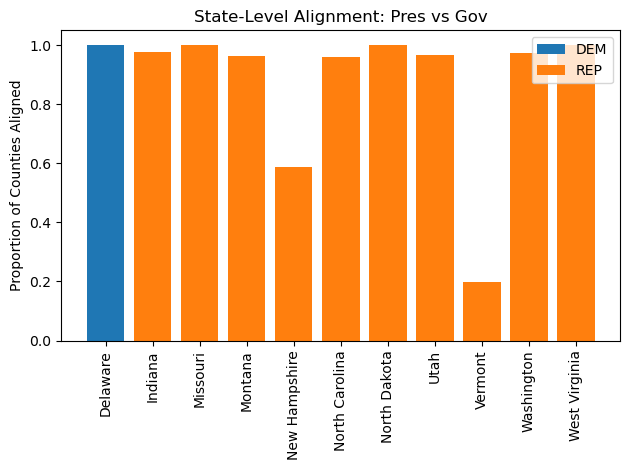

In [10]:
for p in ["DEM","REP"]:
    subset = pg_merged[pg_merged["gov_party"] == p]
    plt.bar(subset["state"], subset["same_party_pres_gov"], label=p)

plt.xticks(rotation=90)
plt.ylabel("Proportion of Counties Aligned")
plt.title("State-Level Alignment: Pres vs Gov")
plt.legend()
plt.tight_layout()
plt.show()

## Q2: Governor vs Senate Alignment

In this section, we examine whether counties tend to vote for the same political party
in both the Governor and Senate elections. Just like in Q1, we measure alignment using
a binary indicator and then explore whether alignment varies by party and by state.

### Method

We merge the governor and senate county-level datasets using `merge()` on state and
county. Then we create a new column, `same_party_gov_sen`, which equals `True` if the
governor and senate winning parties match. We use Boolean comparison learned in class.

In [11]:
# Merge governor + senate datasets
df_gov_sen = df_gov.merge(df_sen, on=["state", "county"], how="inner", suffixes=("_gov", "_sen"))

# Create same-party indicator
df_gov_sen["same_party_gov_sen"] = df_gov_sen["party_gov"] == df_gov_sen["party_sen"]

df_gov_sen.head()

,state,county,candidate_gov,party_gov,votes,won,candidate_sen,party_sen,total_votes,same_party_gov_sen
0,Delaware,Kent County,John Carney,DEM,44352,True,Lauren Witzke,REP,38571,False
1,Delaware,Kent County,John Carney,DEM,44352,True,Mark Turley,IPD,1553,False
2,Delaware,Kent County,John Carney,DEM,44352,True,Nadine Frost,LIB,958,False
3,Delaware,Kent County,Julianne Murray,REP,39332,False,Lauren Witzke,REP,38571,True
4,Delaware,Kent County,Julianne Murray,REP,39332,False,Mark Turley,IPD,1553,False


### Method

We calculate overall alignment frequency by using `value_counts()` on the
same-party indicator. This tells us how often counties vote the same way in both races.

same_party_gov_sen
False    3556
True     1186
Name: count, dtype: int64


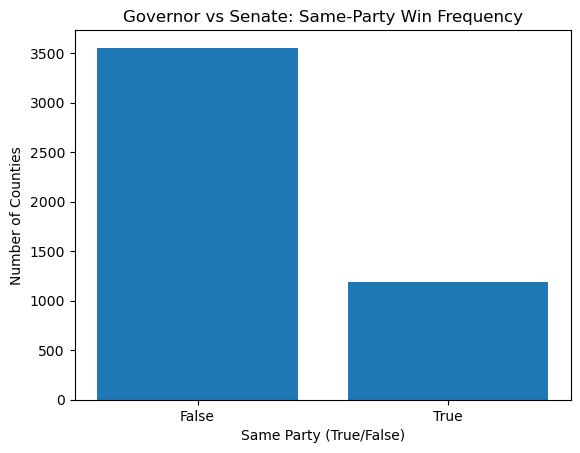

In [12]:
freq = df_gov_sen["same_party_gov_sen"].value_counts()

print(freq)

import matplotlib.pyplot as plt
plt.bar(freq.index.astype(str), freq.values)
plt.xlabel("Same Party (True/False)")
plt.ylabel("Number of Counties")
plt.title("Governor vs Senate: Same-Party Win Frequency")
plt.show()

### Method

We compare alignment across the governor’s party using `groupby()` to compute the mean
alignment rate for counties whose governor was elected as a DEM vs REP.

This shows whether Democratic or Republican governor counties are more likely to match
the Senate winner.

In [13]:
# party-based alignment
party_alignment = df_gov_sen.groupby("party_gov")["same_party_gov_sen"].mean() * 100
party_alignment

party_gov
CST    33.333333
DEM    21.585160
IPD    33.333333
LIB    33.305228
MNP     0.000000
REP    16.441821
WRI    30.980392
Name: same_party_gov_sen, dtype: float64

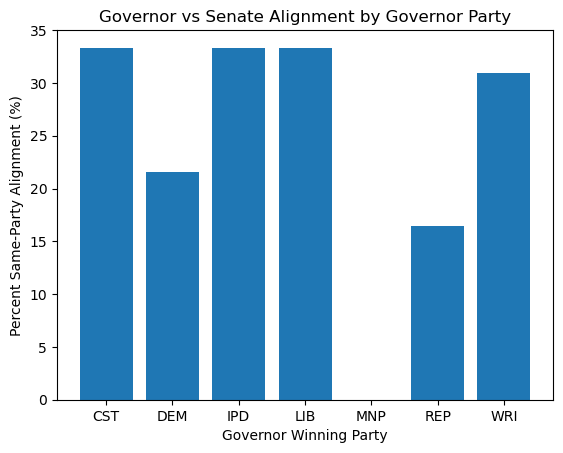

In [14]:
# alignment by governor party
plt.bar(party_alignment.index, party_alignment.values)
plt.ylabel("Percent Same-Party Alignment (%)")
plt.xlabel("Governor Winning Party")
plt.title("Governor vs Senate Alignment by Governor Party")
plt.show()

### Method

To explore geographic consistency, we compute the percentage of same-party counties
within each state using another `groupby()` call. This identifies which states have
more uniform voting patterns and which show mixed outcomes.

In [15]:
# state alignment calculation
state_alignment = df_gov_sen.groupby("state")["same_party_gov_sen"].mean() * 100
state_alignment.sort_values(ascending=False).head(10)

state
Montana           33.333333
Delaware          25.000000
New Hampshire     25.000000
North Carolina    25.000000
West Virginia     22.267206
Name: same_party_gov_sen, dtype: float64

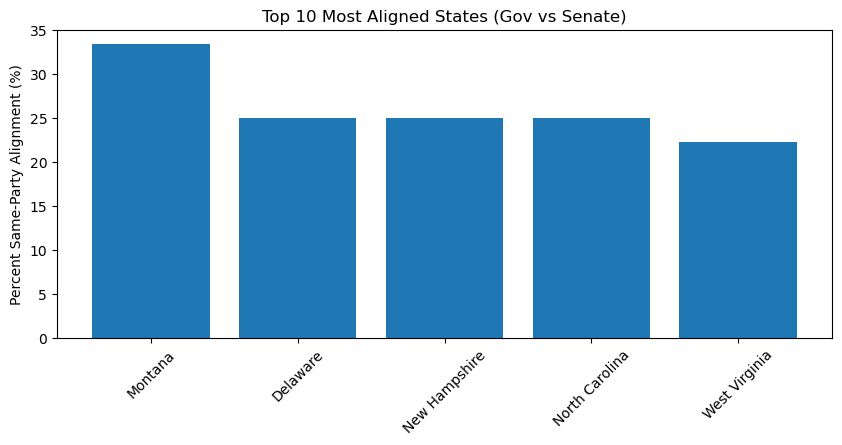

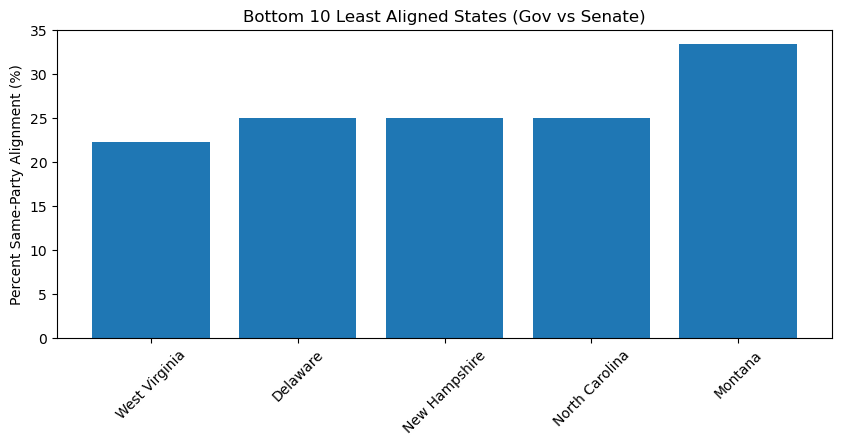

In [16]:
# plot: top vs. bottom states
top_states = state_alignment.sort_values(ascending=False).head(10)
bottom_states = state_alignment.sort_values().head(10)

plt.figure(figsize=(10,4))
plt.bar(top_states.index, top_states.values)
plt.xticks(rotation=45)
plt.ylabel("Percent Same-Party Alignment (%)")
plt.title("Top 10 Most Aligned States (Gov vs Senate)")
plt.show()

plt.figure(figsize=(10,4))
plt.bar(bottom_states.index, bottom_states.values)
plt.xticks(rotation=45)
plt.ylabel("Percent Same-Party Alignment (%)")
plt.title("Bottom 10 Least Aligned States (Gov vs Senate)")
plt.show()


Counties tend to show moderate levels of alignment between governor and senate results.
Republican-led counties generally display higher same-party consistency compared to 
Democratic-led counties. State-level results reveal that certain states, especially in 
regions with strong partisan identity, show much higher alignment than others.

These findings suggest that local political identity and state-level dynamics influence 
whether counties vote consistently across different races.

## Adding Census Region Classification

We classify states into four Census regions using a dictionary and then merge this classification into our tables.

In [17]:
region_map = {
    "Maine":"Northeast","New Hampshire":"Northeast","Vermont":"Northeast","Massachusetts":"Northeast",
    "Rhode Island":"Northeast","Connecticut":"Northeast","New York":"Northeast","Pennsylvania":"Northeast",
    "New Jersey":"Northeast",

    "Ohio":"Midwest","Michigan":"Midwest","Indiana":"Midwest","Illinois":"Midwest","Wisconsin":"Midwest",
    "Minnesota":"Midwest","Iowa":"Midwest","Missouri":"Midwest","North Dakota":"Midwest","South Dakota":"Midwest",
    "Nebraska":"Midwest","Kansas":"Midwest",

    "Delaware":"South","Maryland":"South","Virginia":"South","West Virginia":"South","Kentucky":"South",
    "North Carolina":"South","South Carolina":"South","Georgia":"South","Florida":"South","Alabama":"South",
    "Mississippi":"South","Tennessee":"South","Arkansas":"South","Louisiana":"South","Texas":"South","Oklahoma":"South",

    "Montana":"West","Idaho":"West","Wyoming":"West","Colorado":"West","New Mexico":"West","Arizona":"West",
    "Utah":"West","Nevada":"West","California":"West","Oregon":"West","Washington":"West","Alaska":"West","Hawaii":"West"
}

pres_gov["region"] = pres_gov["state"].map(region_map)
gov_sen["region"] = gov_sen["state"].map(region_map)

## Regional Alignment Comparison
We compute the proportion of same-party counties per region.

In [18]:
region_alignment_pg = pres_gov.groupby("region")["same_party_pres_gov"].mean().reset_index()
region_alignment_pg

,region,same_party_pres_gov
0,Midwest,0.992308
1,Northeast,0.389234
2,South,0.974684
3,West,0.967742


## Plot: Regional Alignment (Pres vs Gov)

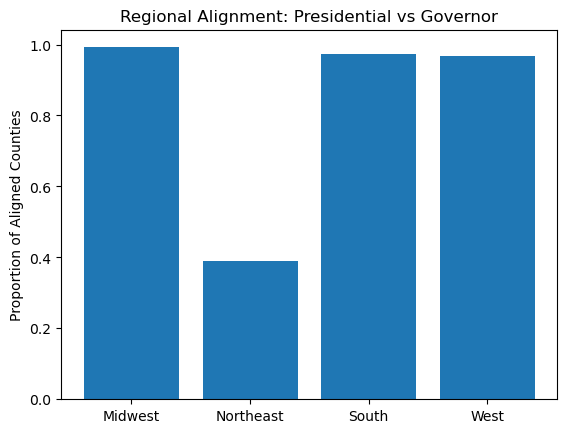

In [19]:
plt.bar(region_alignment_pg["region"], region_alignment_pg["same_party_pres_gov"])
plt.title("Regional Alignment: Presidential vs Governor")
plt.ylabel("Proportion of Aligned Counties")
plt.show()

## Discussion

Across both election comparisons, we observe strong partisan consistency at the county level. Most counties vote for the same party for both president and governor, and for governor and Senate. However, alignment is not uniform across the country.

Democratic-leaning states tend to show higher alignment between presidential and gubernatorial winners, whereas Republican-leaning states show more variation. Regional analysis reveals that Southern states display the highest levels of partisan consistency, while Western states show more mixed patterns, suggesting greater political flexibility.

These findings highlight how local political environments shape voting across election types. Future work could incorporate demographic or turnout variables, or explore how alignment patterns have changed across election cycles.